# Warehouse KPI Analysis

Picking accuracy, error patterns and expiry risk for a refrigerated food
warehouse. The dataset is **synthetic but modeled on real operations** I
worked in: temperature zones (-18°C / -25°C), lot codes with expiry dates,
and a hard company target — **picking error rate below 1%**.

Questions this notebook answers:
1. Are we below the 1% error-rate target, and is the trend stable?
2. Which pickers need coaching, which can mentor?
3. Which error types dominate?
4. Where does volume go, and which lots are at expiry risk?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

TARGET = 1.0  # % — company target for picking error rate

lines = pd.read_csv("../data/order_lines.csv", parse_dates=["pick_date"], keep_default_na=False)
products = pd.read_csv("../data/products.csv")
lots = pd.read_csv("../data/lots.csv", parse_dates=["received_date", "expiry_date"])

lines = lines.merge(products, on="sku")
lines["is_error"] = lines["error_type"] != ""
print(f"{len(lines):,} picked lines · {lines['pick_date'].min().date()} → {lines['pick_date'].max().date()}")
lines.head(3)

46,247 picked lines · 2026-01-05 → 2026-07-04


,line_id,order_id,pick_date,picker_id,sku,lot_code,qty_ordered,error_type,product_name,category,storage_zone,is_error
0,1,5001,2026-01-05,P06,SKU1019,L202608-0085,3,,Veg burger x4,Ready meals,-18C,False
1,2,5001,2026-01-05,P06,SKU1007,L202603-0028,3,,Salmon portions 500g,Fish,-25C,False
2,3,5001,2026-01-05,P06,SKU1000,L202546-0001,12,,Peas 450g,Vegetables,-18C,False


## 1. Overall picking accuracy

The error rate is the share of picked lines with any error. One number,
but it decides whether the shift review starts calm or tense.

In [2]:
total = len(lines)
errors = int(lines["is_error"].sum())
rate = 100 * errors / total
print(f"Picked lines : {total:,}")
print(f"Error lines  : {errors:,}")
print(f"Error rate   : {rate:.2f}%  (target < {TARGET}%)  →  {'✅ below target' if rate < TARGET else '🔴 ABOVE TARGET'}")

Picked lines : 46,247
Error lines  : 403
Error rate   : 0.87%  (target < 1.0%)  →  ✅ below target


## 2. Weekly trend

A good overall number can hide a bad month. Weekly buckets show whether
the process is under control or drifting.

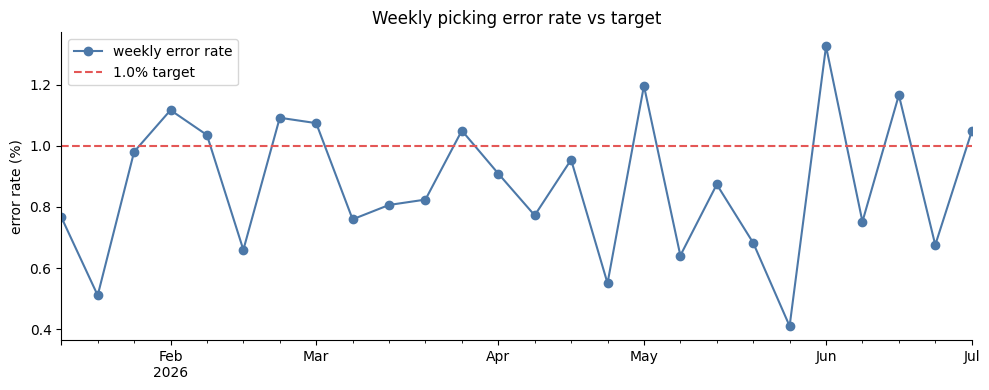

In [3]:
weekly = (lines.set_index("pick_date")
               .resample("W")["is_error"]
               .agg(rate="mean", lines="count"))
weekly["rate_pct"] = 100 * weekly["rate"]

ax = weekly["rate_pct"].plot(marker="o", color="#4c78a8", label="weekly error rate")
ax.axhline(TARGET, color="#e45756", linestyle="--", label=f"{TARGET}% target")
ax.set_ylabel("error rate (%)")
ax.set_xlabel("")
ax.set_title("Weekly picking error rate vs target")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Error rate by picker

On the floor this is the coaching list. Anyone above the line gets support
(shadowing, double checks on expiry-sensitive lines); the best performer is
the natural mentor.

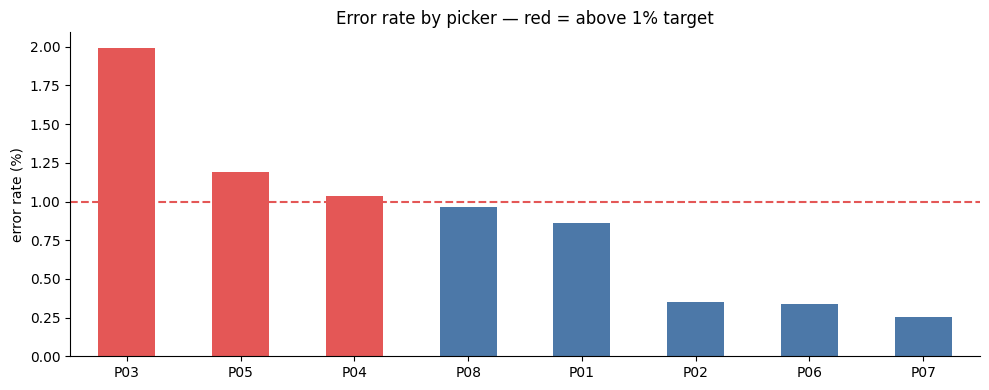

,lines,rate_pct
picker_id,,
P03,5769,1.99
P05,5872,1.19
P04,5590,1.04
P08,5790,0.97
P01,5688,0.86
P02,6022,0.35
P06,5615,0.34
P07,5901,0.25


In [4]:
by_picker = (lines.groupby("picker_id")["is_error"]
                  .agg(rate="mean", lines="count")
                  .assign(rate_pct=lambda d: 100 * d["rate"])
                  .sort_values("rate_pct", ascending=False))

colors = ["#e45756" if r > TARGET else "#4c78a8" for r in by_picker["rate_pct"]]
ax = by_picker["rate_pct"].plot(kind="bar", color=colors)
ax.axhline(TARGET, color="#e45756", linestyle="--")
ax.set_ylabel("error rate (%)")
ax.set_xlabel("")
ax.set_title("Error rate by picker — red = above 1% target")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

by_picker.round({"rate_pct": 2})[["lines", "rate_pct"]]

## 4. What actually goes wrong (error mix)

Different errors need different fixes: wrong quantity → scanner prompts and
end-of-line checks; wrong item → slotting and label clarity; expired lot →
FIFO discipline. The Pareto tells us where training time pays off most.

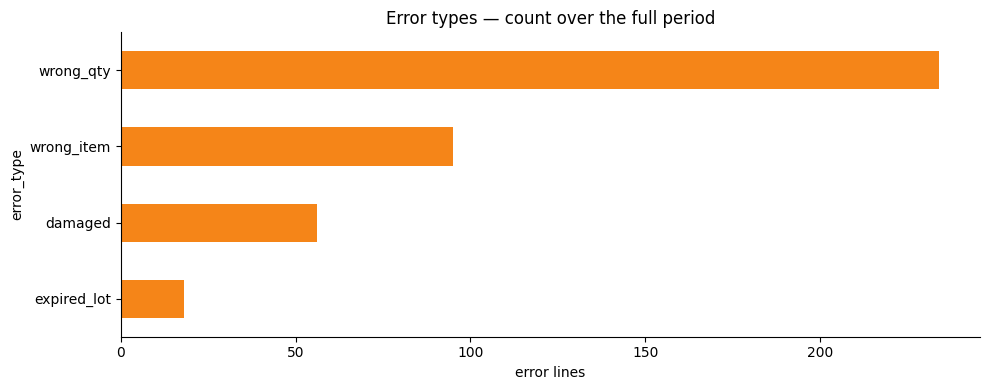

,count,share_%
error_type,,
wrong_qty,234,58.1
wrong_item,95,23.6
damaged,56,13.9
expired_lot,18,4.5


In [5]:
mix = lines.loc[lines["is_error"], "error_type"].value_counts()

ax = mix.sort_values().plot(kind="barh", color="#f58518")
ax.set_title("Error types — count over the full period")
ax.set_xlabel("error lines")
plt.tight_layout()
plt.show()

share = (100 * mix / mix.sum()).round(1)
pd.DataFrame({"count": mix, "share_%": share})

## 5. Volume by category and temperature zone

Where the picking work actually goes. Deep-frozen (-25°C) lines take longer
per pick (gloves, colder cells), so zone mix matters when comparing pickers
or planning shifts.

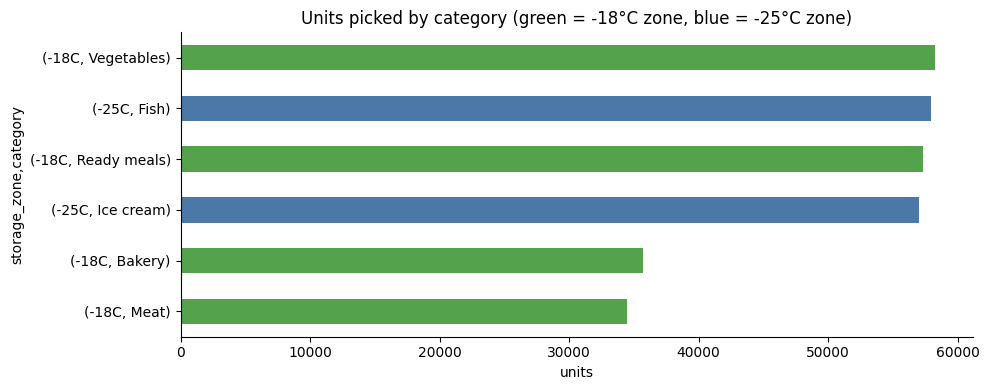

In [6]:
vol = (lines.groupby(["storage_zone", "category"])["qty_ordered"]
            .sum()
            .sort_values(ascending=True))

ax = vol.plot(kind="barh", color=["#54a24b" if z == "-18C" else "#4c78a8" for z, _ in vol.index])
ax.set_title("Units picked by category (green = -18°C zone, blue = -25°C zone)")
ax.set_xlabel("units")
plt.tight_layout()
plt.show()

## 6. Expiry risk — the list that drives tomorrow morning

Lots within 30 days of expiry, as of the last activity date. In a real
warehouse this list decides FIFO priorities and promo pushes before goods
turn into waste.

In [7]:
as_of = lines["pick_date"].max()
risk = lots.assign(days_to_expiry=(lots["expiry_date"] - as_of).dt.days)
risk = (risk[risk["days_to_expiry"].between(0, 30)]
        .merge(products, on="sku")
        .sort_values("days_to_expiry")
        [["lot_code", "product_name", "category", "expiry_date", "days_to_expiry", "qty_received"]])

print(f"As of {as_of.date()} — {len(risk)} lots at risk in the next 30 days")
risk.reset_index(drop=True)

As of 2026-07-04 — 6 lots at risk in the next 30 days


,lot_code,product_name,category,expiry_date,days_to_expiry,qty_received
0,L202602-0054,Lemon sorbet 750ml,Ice cream,2026-07-07,3,120
1,L202602-0067,Lasagne 600g,Ready meals,2026-07-07,3,240
2,L202603-0028,Salmon portions 500g,Fish,2026-07-11,7,240
3,L202603-0023,Cod fillets 400g,Fish,2026-07-13,9,360
4,L202613-0036,Seafood mix 400g,Fish,2026-07-25,21,120
5,L202613-0107,Strudel 400g,Bakery,2026-07-27,23,120


## Conclusions

- **Overall error rate is 0.87%, below the 1% target**, and the weekly
  rate moves between 0.41% and 1.33% with no visible drift. Still, 9 of
  26 weeks close above 1%: the average is safe, a single week is not.
- **Three pickers sit above target**: P03 at 1.99% is the outlier, P05
  (1.19%) and P04 (1.04%) are borderline. P03 is the classic new-hire
  pattern — pairing them with the best performer (0.25%) is the
  cheapest fix.
- **Wrong quantity dominates the error mix** — end-of-line quantity checks
  would attack more than half of all errors at once.
- A handful of lots enter the **30-day expiry window**; FIFO discipline on
  those SKUs prevents write-offs.

*Next steps: cost-weight the errors (an expired-lot pick costs more than a
wrong quantity), and add picker lines-per-hour to read accuracy together
with speed.*